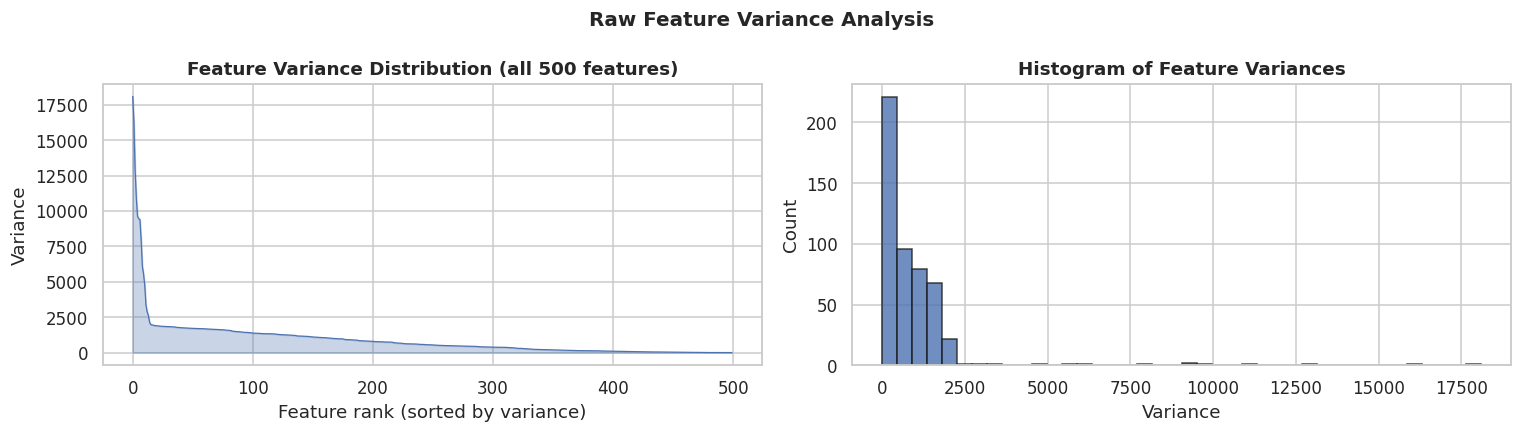

Max variance : 18104.93
Min variance : 0.35
Mean variance: 911.89

⚠️  Variance ranges widely — scaling is essential!


In [5]:
# Feature variance distribution across all 500 features
variances = X_all.var().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(len(variances)), variances.values, color='#4C72B0', linewidth=0.8)
axes[0].fill_between(range(len(variances)), variances.values, alpha=0.3, color='#4C72B0')
axes[0].set_title('Feature Variance Distribution (all 500 features)', fontweight='bold')
axes[0].set_xlabel('Feature rank (sorted by variance)')
axes[0].set_ylabel('Variance')

axes[1].hist(variances.values, bins=40, color='#4C72B0', edgecolor='k', alpha=0.8)
axes[1].set_title('Histogram of Feature Variances', fontweight='bold')
axes[1].set_xlabel('Variance'); axes[1].set_ylabel('Count')

plt.suptitle('Raw Feature Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Max variance : {variances.max():.2f}")
print(f"Min variance : {variances.min():.2f}")
print(f"Mean variance: {variances.mean():.2f}")
print(f"\n⚠️  Variance ranges widely — scaling is essential!")

In [6]:
# ── DELIVERABLE 1: StandardScaler Implementation ────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print("=== StandardScaler Results ===")
print(f"Input  shape : {X_all.shape}")
print(f"Output shape : {X_scaled.shape}")
print()
print(f"Before scaling — mean (f0–f4): {X_all.iloc[:, :5].mean().round(2).values}")
print(f"Before scaling — std  (f0–f4): {X_all.iloc[:, :5].std().round(2).values}")
print()
print(f"After scaling  — mean (f0–f4): {X_scaled[:, :5].mean(axis=0).round(4)}")
print(f"After scaling  — std  (f0–f4): {X_scaled[:, :5].std(axis=0).round(4)}")
print()
print("✅ All features now have mean≈0 and std≈1")

=== StandardScaler Results ===
Input  shape : (2000, 500)
Output shape : (2000, 500)

Before scaling — mean (f0–f4): [481.72 483.45 510.17 483.38 501.61]
Before scaling — std  (f0–f4): [ 6.42 30.19 38.9   9.06 41.39]

After scaling  — mean (f0–f4): [-0.  0.  0. -0. -0.]
After scaling  — std  (f0–f4): [1. 1. 1. 1. 1.]

✅ All features now have mean≈0 and std≈1


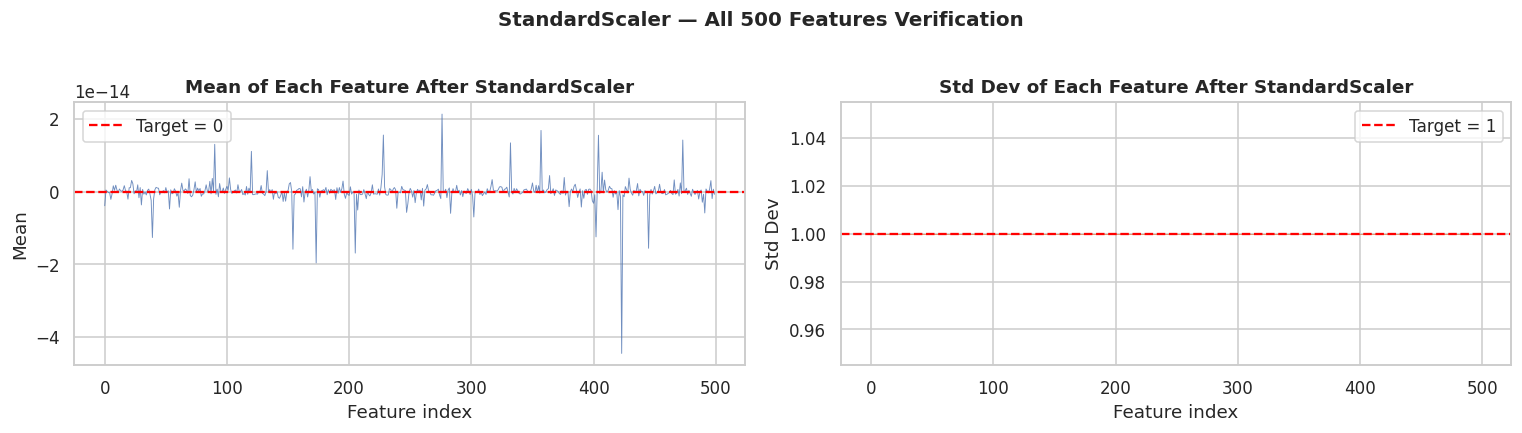

Global mean across all features: -0.000000  ✅ ≈ 0
Global std  across all features: 1.000000  ✅ ≈ 1


In [8]:
# Mean and Std across all 500 features after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

means_after = X_scaled.mean(axis=0)
stds_after  = X_scaled.std(axis=0)

axes[0].plot(means_after, color='#4C72B0', linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Target = 0')
axes[0].set_title('Mean of Each Feature After StandardScaler', fontweight='bold')
axes[0].set_xlabel('Feature index'); axes[0].set_ylabel('Mean')
axes[0].legend()

axes[1].plot(stds_after, color='#DD8452', linewidth=0.6, alpha=0.8)
axes[1].axhline(1, color='red', linestyle='--', linewidth=1.5, label='Target = 1')
axes[1].set_title('Std Dev of Each Feature After StandardScaler', fontweight='bold')
axes[1].set_xlabel('Feature index'); axes[1].set_ylabel('Std Dev')
axes[1].legend()

plt.suptitle('StandardScaler — All 500 Features Verification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Global mean across all features: {means_after.mean():.6f}  ✅ ≈ 0")
print(f"Global std  across all features: {stds_after.mean():.6f}  ✅ ≈ 1")

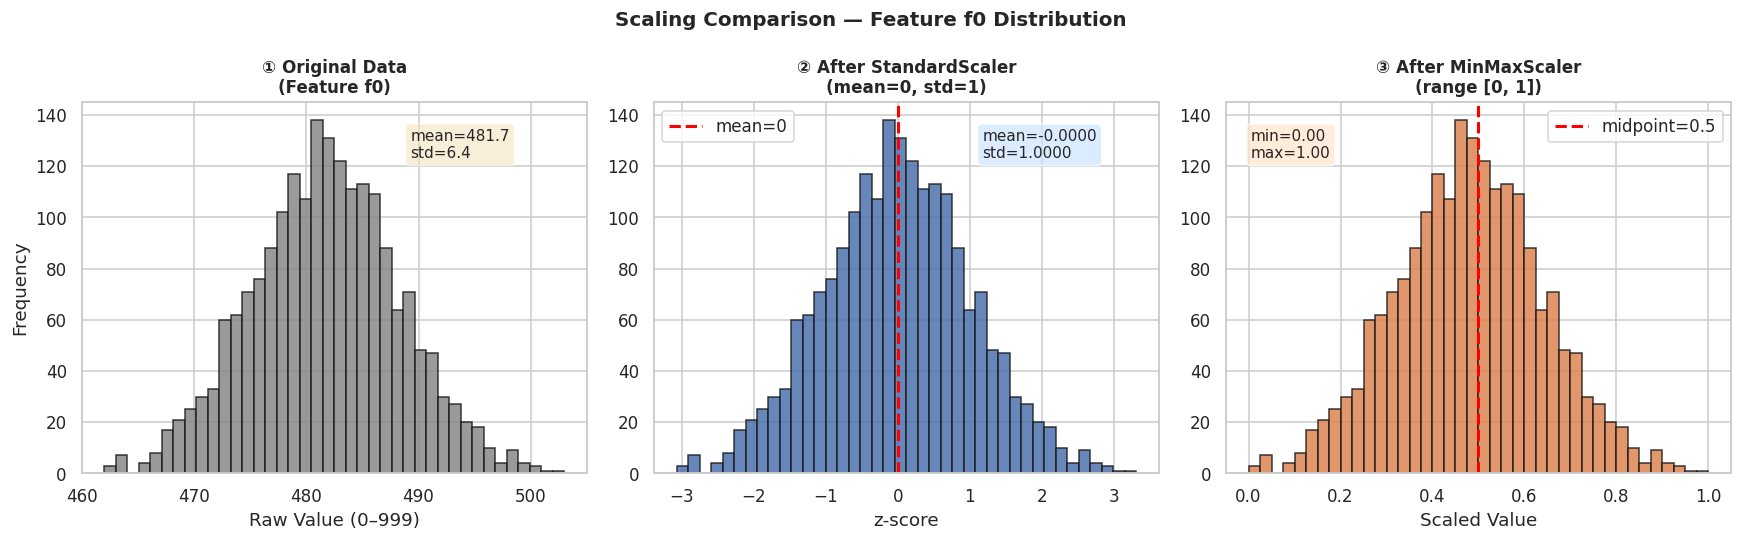

In [10]:
# Side-by-side: Raw vs StandardScaler vs MinMaxScaler (Feature 0)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(X_all.iloc[:, 0], bins=40, color='#888888', edgecolor='k', alpha=0.85)
axes[0].set_title('① Original Data\n(Feature f0)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Raw Value (0–999)'); axes[0].set_ylabel('Frequency')
axes[0].annotate(f"mean={X_all.iloc[:,0].mean():.1f}\nstd={X_all.iloc[:,0].std():.1f}",
                 xy=(0.65,0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].hist(X_scaled[:, 0], bins=40, color='#4C72B0', edgecolor='k', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='mean=0')
axes[1].set_title('② After StandardScaler\n(mean=0, std=1)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('z-score'); axes[1].legend()
axes[1].annotate(f"mean={X_scaled[:,0].mean():.4f}\nstd={X_scaled[:,0].std():.4f}",
                 xy=(0.65,0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='#cce5ff', alpha=0.7))

axes[2].hist(X_minmax[:, 0], bins=40, color='#DD8452', edgecolor='k', alpha=0.85)
axes[2].axvline(0.5, color='red', linestyle='--', linewidth=2, label='midpoint=0.5')
axes[2].set_title('③ After MinMaxScaler\n(range [0, 1])', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Scaled Value'); axes[2].legend()
axes[2].annotate(f"min={X_minmax[:,0].min():.2f}\nmax={X_minmax[:,0].max():.2f}",
                 xy=(0.05,0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='#ffe5cc', alpha=0.7))

plt.suptitle('Scaling Comparison — Feature f0 Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()